# **Problem Statement**

## **Business Context**

Health insurance costs vary significantly among individuals based on factors such as age, BMI, smoking status, number of dependents, and residential region. Accurately understanding these factors helps insurance companies estimate medical expenses, set appropriate premiums, and manage financial risk.

This project analyzes health insurance data to identify the key factors influencing insurance charges and develops a machine learning model to predict expected medical expenses. The insights can support better pricing decisions, personalized insurance plans, and improved cost management.

## **Objective**

The objective of this project is to:

* Analyze the factors influencing health insurance charges.
* Explore relationships between age, BMI, smoking status, children, sex, and region.
* Build and evaluate linear regression models to predict insurance charges.
* Compare model performance using MSE and R² scores.
* Provide insights that can support accurate premium estimation and better risk management.

## **Data Description**



The dataset contains information about individuals and their medical insurance costs. It includes demographic, health, and lifestyle factors that may influence insurance charges.



- **Age:** Age of the individual.
- **Sex:** Gender of the individual.
- **BMI:** Body Mass Index.
- **Children:** Number of dependents.
- **Smoker:** Smoking status.
- **Region:** Residential area.
- **Charges:** Medical insurance cost, used as the target variable.

## **Installing and Importing Necessary Libraries**

In [1]:
!pip install matplotlib seaborn scikit-learn pandas

This command installs the Python libraries required for the analysis:

```python
!pip install matplotlib seaborn scikit-learn pandas
```

- `!` runs a terminal command from inside the notebook.
- `matplotlib` is used to create charts and graphs.
- `seaborn` provides statistical visualizations.
- `scikit-learn` provides machine-learning models and evaluation tools.
- `pandas` is used for loading, cleaning, and analyzing tabular data.

The command ensures that these packages are available before running the notebook’s data analysis and machine-learning code.

In [2]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression 

from sklearn.metrics import mean_squared_error, r2_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

This code imports the libraries needed for data analysis, visualization, preprocessing, and linear regression:

- `pandas`: Loads, cleans, and analyzes tabular insurance data.
- `numpy`: Performs numerical calculations.
- `matplotlib.pyplot`: Creates charts and graphs.
- `seaborn`: Creates statistical visualizations.
- `LinearRegression`: Builds linear regression models to predict insurance charges.
- `mean_squared_error`: Measures prediction error; lower values are better.
- `r2_score`: Measures how much variation in charges the model explains; values closer to `1` are better.
- `train_test_split`: Divides data into training and testing sets.
- `StandardScaler`: Standardizes numerical features.
- `OneHotEncoder`: Converts categorical variables into numerical values.

Together, these imports support the complete workflow: loading data, exploring patterns, preparing features, training regression models, and evaluating their performance.

# **Loading the data**

The dataset is loaded from a CSV file using pandas.read_csv() and stored in the variable data. This DataFrame contains demographic, health, lifestyle, and insurance-cost information used for analysis and prediction.The current file path is specific to your computer, so it may need to be changed if the CSV file is moved.

In [3]:
data=pd.read_csv(r"C:\Users\acer\OneDrive\Desktop\GEN AI\Machine Learning\insurance_prediction (1).csv")

This code loads the health insurance CSV file into a pandas DataFrame:

```python
data = pd.read_csv(
    r"C:\Users\acer\OneDrive\Desktop\GEN AI\insurance_prediction (1).csv"
)
```

- `pd.read_csv()` reads the CSV file.
- `data` stores the dataset in a tabular DataFrame.
- The `r` makes the Windows file path a raw string, so backslashes work correctly.
- The dataset can now be inspected and analyzed using commands such as `data.head()`, `data.shape`, `data.info()`, and `data.describe()`.

The path is computer-specific, so it must be changed if the CSV file is moved or used on another computer.

# **Data Overview**


The data overview section examines the structure, contents, statistical properties, and quality of the insurance dataset.

- `data.shape` displays the number of rows and columns.
- `data.head(10)` shows the first ten records.
- `data.tail(10)` shows the last ten records.
- `data.info()` displays column names, data types, and missing-value information.
- `data.describe()` provides statistical summaries for numerical columns.
- `data.describe().T` presents the same summary in a transposed format for easier reading.
- `data.describe(include='object')` summarizes categorical columns such as `sex`, `smoker`, and `region`.
- Duplicate records are identified using `data.duplicated()`.
- Duplicate rows are removed using `data.drop_duplicates()`.
- `data.transpose()` displays the dataset with rows and columns exchanged, making individual records easier to inspect.

This step helps verify the dataset before performing exploratory analysis and machine-learning modeling.

In [5]:
data.shape

(1338, 7)

The `data.shape` output returns a tuple in the form `(rows, columns)`.

- **Rows:** Number of individual insurance records.
- **Columns:** Number of variables, including demographic features, health-related factors, categorical attributes, and the target variable `charges`.

This confirms the dataset’s size and helps determine whether it contains sufficient observations for exploratory analysis and machine-learning modeling.

In [6]:
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


The `data.head(10)` command displays the first ten records of the dataset.

It helps to:

- Verify that the data was loaded correctly.
- Inspect column names and sample values.
- Understand the structure of demographic, health, categorical, and target variables.
- Detect obvious issues such as incorrect values, missing data, or formatting errors.

This provides an initial view of the insurance dataset before performing detailed analysis.

In [7]:
data.tail(10)

,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


The `data.tail(10)` command displays the last ten records of the dataset.

It helps to:

- Confirm that the dataset loaded completely.
- Inspect the final rows and verify their values.
- Identify missing, inconsistent, or incorrectly formatted data.
- Check whether the dataset ends normally without unexpected records.

This provides a final validation of the dataset before further analysis and preprocessing.

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


The `data.info()` command provides a concise summary of the dataset.

It shows:

- The number of rows and columns.
- Column names and their data types.
- The number of non-null values in each column.
- Possible missing values.
- The dataset’s memory usage.

This confirms whether variables have appropriate data types and whether the dataset requires missing-value treatment before analysis and model training.

In [9]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


The `data.describe()` command provides statistical summaries of numerical columns, including:

- **count:** Number of non-missing observations.
- **mean:** Average value.
- **std:** Standard deviation or data spread.
- **min:** Minimum value.
- **25%:** First quartile.
- **50%:** Median value.
- **75%:** Third quartile.
- **max:** Maximum value.

For this insurance dataset, it summarizes variables such as `age`, `bmi`, `children`, and `charges`. This helps identify typical values, variability, ranges, and possible outliers before modeling.

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


The `data.describe().T` command produces the same statistical summary as `data.describe()`, but transposes it.

- Each **row** represents a numerical column, such as `age`, `bmi`, `children`, or `charges`.
- Each **column** displays a statistic: `count`, `mean`, `std`, `min`, quartiles, and `max`.

This format makes it easier to compare variables, identify their ranges and variability, detect possible outliers, and assess the dataset before modeling.

In [11]:
data.describe(include='object')

C:\Users\acer\AppData\Local\Temp\ipykernel_13616\3382516499.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


The `data.describe(include='object')` command summarizes categorical columns such as `sex`, `smoker`, and `region`.

It shows:

- **count:** Number of non-missing categorical values.
- **unique:** Number of distinct categories.
- **top:** Most frequently occurring category.
- **freq:** Number of times the most frequent category appears.

This helps understand category distribution, detect missing values, and identify possible imbalances before encoding categorical variables for machine learning.

In [12]:
duplicate_rows = data[data.duplicated()]

This command identifies all duplicate rows in the DataFrame and stores them in `duplicate_rows`.

- `data.duplicated()` returns `True` for rows that repeat an earlier row.
- `data[...]` filters and displays only those duplicate records.
- The original dataset is not changed.

This helps detect repeated insurance records before removing them with `data.drop_duplicates()`.

In [13]:
print(f"Number of duplicate rows: {len(duplicate_rows)}")

Number of duplicate rows: 1


This command counts and prints the number of duplicate rows found in `duplicate_rows`.

- `len(duplicate_rows)` returns the number of duplicate records.
- `f"..."` inserts that number into the message.
- The output indicates how many repeated insurance records exist in the dataset.

For example:

```text
Number of duplicate rows: 5
```

means five duplicate rows were identified.

In [14]:
duplicate_rows = data[data.duplicated()]

print(f"Number of duplicate rows: {len(duplicate_rows)}")
duplicate_rows

Number of duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


This code:

1. Identifies duplicate records and stores them in `duplicate_rows`.
2. Counts and prints the number of duplicate rows.
3. Displays the duplicate records.

The output helps verify whether repeated insurance records exist before removing them with `data.drop_duplicates()`. If no duplicates exist, `duplicate_rows` will be empty and the count will be `0`.

In [15]:
data = data.drop_duplicates()
print(f"Shape after removi Sng duplicates: {data.shape}")

Shape after removi Sng duplicates: (1337, 7)


```python
data = data.drop_duplicates()
print(f"Shape after removing duplicates: {data.shape}")
```

- `drop_duplicates()` removes repeated rows from `data`.
- The cleaned DataFrame is assigned back to `data`.
- `data.shape` displays the remaining number of rows and columns.

For example, `(1335, 7)` means the dataset contains **1,335 rows and 7 columns** after duplicate removal.

Note: Correct the message typo to **“Shape after removing duplicates”**.

In [16]:
data.transpose()

,0,1,2,3,4,5,6,7,8,9,...,1328,1329,1330,1331,1332,1333,1334,1335,1336,1337
age,19,18,28,33,32,31,46,37,37,60,...,23,52,57,23,52,50,18,18,21,61
sex,female,male,male,male,male,female,female,female,male,female,...,female,male,female,female,female,male,female,female,female,female
bmi,27.9,33.77,33.0,22.705,28.88,25.74,33.44,27.74,29.83,25.84,...,24.225,38.6,25.74,33.4,44.7,30.97,31.92,36.85,25.8,29.07
children,0,1,3,0,0,0,1,3,2,0,...,2,2,2,0,3,3,0,0,0,0
smoker,yes,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,yes
region,southwest,southeast,southeast,northwest,northwest,southeast,southeast,northwest,northeast,northwest,...,northeast,southwest,southeast,southwest,southwest,northwest,northeast,southeast,southwest,northwest
charges,16884.924,1725.5523,4449.462,21984.47061,3866.8552,3756.6216,8240.5896,7281.5056,6406.4107,28923.13692,...,22395.74424,10325.206,12629.1656,10795.93733,11411.685,10600.5483,2205.9808,1629.8335,2007.945,29141.3603


`data.transpose()` swaps the rows and columns of the DataFrame.

- Original rows become columns.
- Original columns become rows.
- Each insurance variable (`age`, `bmi`, `charges`, etc.) is displayed vertically.
- The data itself is not permanently changed unless assigned back:

```python
data = data.transpose()
```

It is useful for inspecting the dataset in an alternative layout.

#  **EXPLORATORY DATA ANALYSIS**

Exploratory Data Analysis (EDA) is performed to understand the dataset through statistical summaries and visualizations. It helps identify data distributions, relationships between variables, patterns, and possible outliers.

In this project, EDA examines:

- The distribution of age, BMI, and insurance charges.
- The number of individuals by sex, smoking status, and region.
- The relationship between age and insurance charges.
- Differences in charges between smokers and non-smokers.
- The effect of sex, number of children, and region on insurance charges.
- Correlations among numerical variables such as age, BMI, and charges.

These analyses provide useful insights into the factors that may influence medical insurance costs and help guide the selection of variables for machine-learning models.

# **Univariate Analysis**

Univariate analysis examines each variable individually to understand its distribution, frequency, and range.

- The **age distribution** shows the age range and concentration of individuals in the dataset.
- The **sex count plot** compares the number of male and female individuals.
- The **BMI distribution** shows the common BMI range and identifies unusually low or high values.
- The **smoker count plot** displays the proportion of smokers and non-smokers.
- The **region count plot** shows how individuals are distributed across residential regions.
- The **charges boxplot** presents the spread of insurance costs and helps identify possible outliers.

This analysis provides an initial understanding of the dataset and helps identify imbalances, skewed distributions, and unusual observations before performing bivariate analysis and modeling.

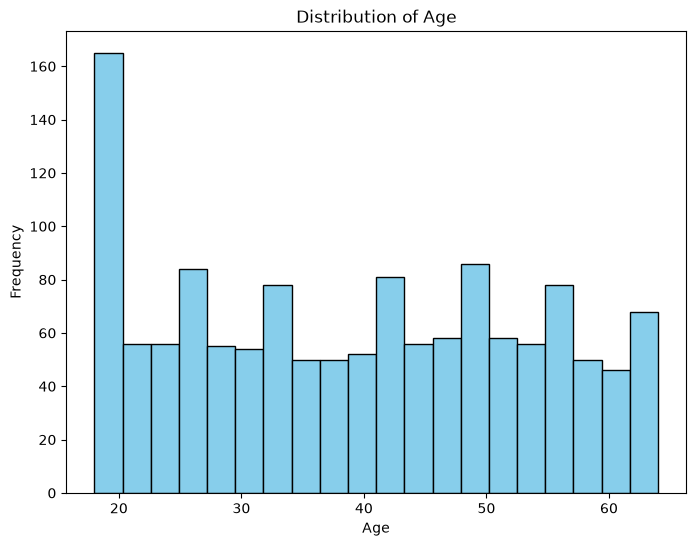

In [17]:
plt.figure(figsize=(8,6))
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

This code creates a histogram showing how individuals’ ages are distributed in the dataset.

- `plt.figure(figsize=(8,6))` sets the chart size.
- `plt.hist(data['age'], bins=20, ...)` divides ages into 20 intervals and counts records in each interval.
- `plt.title()` adds the chart title.
- `plt.xlabel()` labels the horizontal axis as age.
- `plt.ylabel()` labels the vertical axis as frequency.
- `plt.show()` displays the chart.

The histogram helps identify the common age ranges, overall spread, concentration, and possible unusual age values.

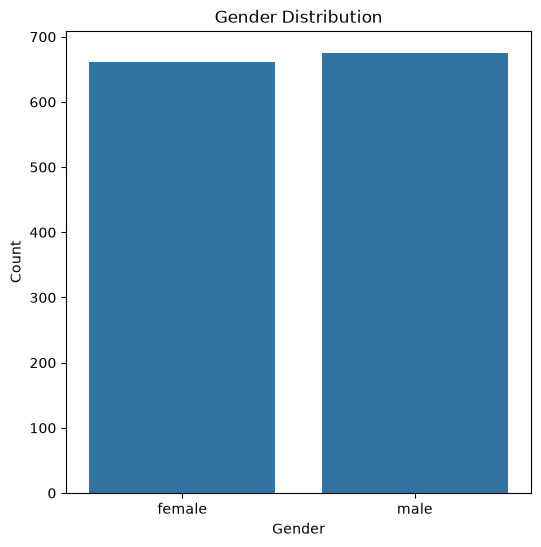

In [18]:
plt.figure(figsize=(6, 6))
sns.countplot(x='sex', data=data)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

This code creates a count plot showing the number of individuals in each gender category.

- `plt.figure(figsize=(6, 6))` sets the chart size.
- `sns.countplot(x='sex', data=data)` counts records for each `sex` category.
- `plt.title()` adds the chart title.
- `plt.xlabel()` labels the x-axis.
- `plt.ylabel()` labels the y-axis.
- `plt.show()` displays the chart.

The plot helps compare gender representation and identify whether the dataset is balanced or has more records in one category.

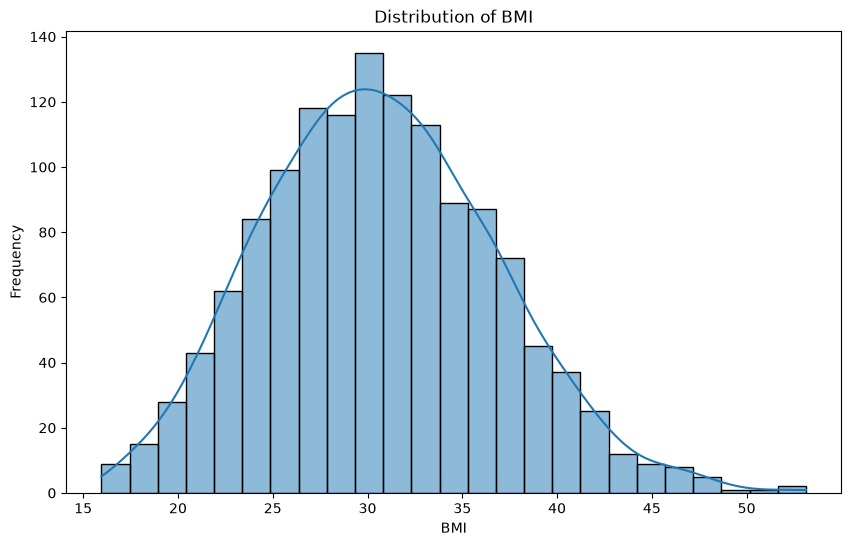

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(data['bmi'], kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

This code creates a histogram showing the distribution of BMI values.

- `plt.figure(figsize=(10, 6))` sets the chart size.
- `sns.histplot(data['bmi'], kde=True)` displays BMI frequencies and adds a smooth density curve.
- `plt.title()` adds the chart title.
- `plt.xlabel()` labels the x-axis as BMI.
- `plt.ylabel()` labels the y-axis as frequency.
- `plt.show()` displays the chart.

The graph helps identify the typical BMI range, distribution shape, concentration of values, spread, and possible unusually low or high BMI values.

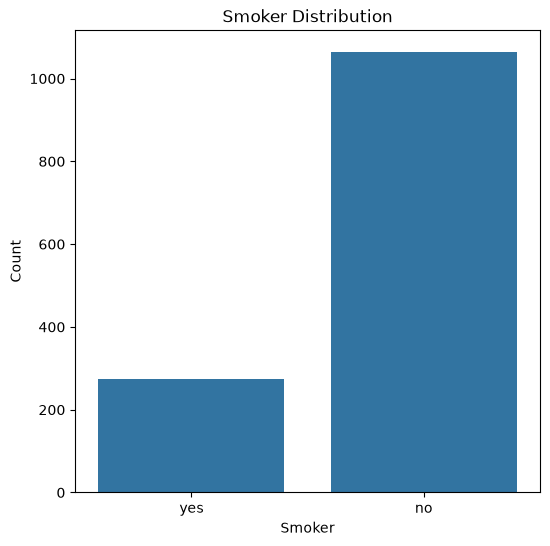

In [20]:
plt.figure(figsize=(6, 6))
sns.countplot(x='smoker', data=data) 
plt.title('Smoker Distribution')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()

This code creates a count plot showing the number of smokers and non-smokers in the dataset.

- `sns.countplot(x='smoker', data=data)` counts each smoking-status category.
- The x-axis shows smoking status (`yes` or `no`).
- The y-axis shows the number of individuals.
- The plot reveals whether smokers and non-smokers are evenly represented.
- In this dataset, non-smokers are generally much more numerous than smokers.

This distribution is important because smoking status may strongly influence insurance charges.

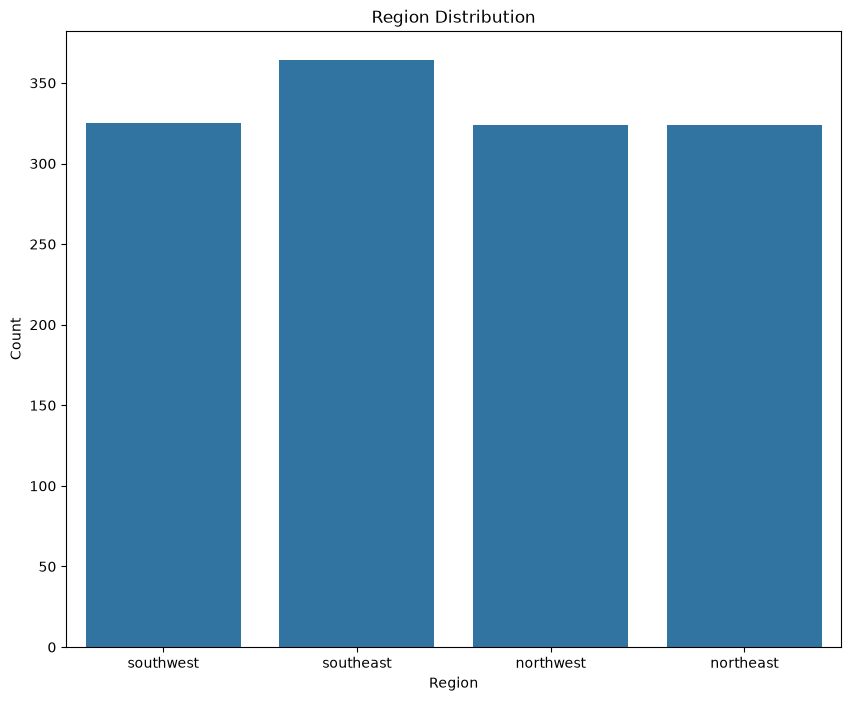

In [21]:
plt.figure(figsize=(10, 8))
sns.countplot(x='region', data=data)
plt.title('Region Distribution')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

This count plot shows the number of individuals from each residential region.

- The x-axis represents the regions.
- The y-axis represents the number of records.
- Taller bars indicate regions with more individuals.
- Similar bar heights suggest a relatively balanced regional distribution.
- Differences in bar heights indicate regional representation imbalance.

This helps determine whether the dataset is evenly distributed across regions and whether region should be considered in insurance-charge prediction.

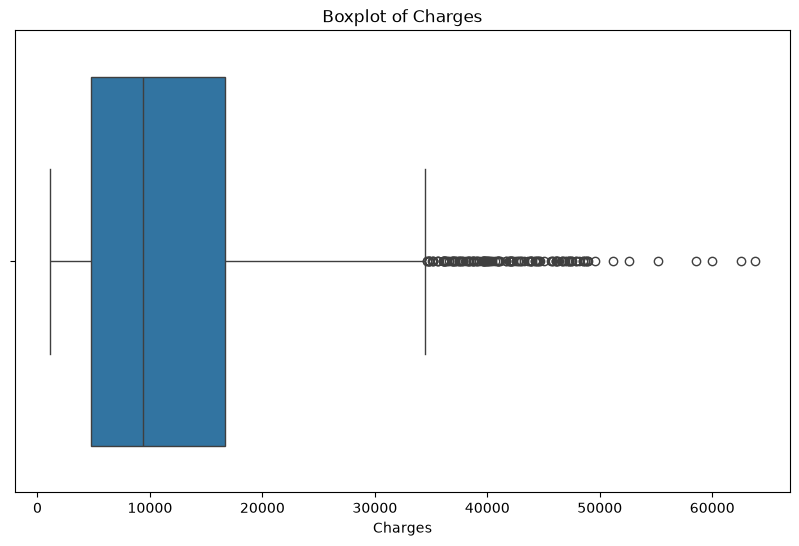

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='charges', data=data)
plt.title('Boxplot of Charges')
plt.xlabel('Charges')
plt.show()

This boxplot summarizes the distribution of insurance charges.

- The line inside the box represents the **median** charge.
- The box shows the middle 50% of charges, known as the **interquartile range (IQR)**.
- The whiskers show the typical minimum and maximum values.
- Points beyond the whiskers represent possible **outliers**.
- Insurance charges are typically **right-skewed**, with some individuals having unusually high charges.

These high values may be associated with factors such as smoking, age, or BMI and should be considered during modeling.

# **Bivariate Analysis**

Bivariate analysis examines the relationship between two variables to identify patterns and understand how different factors influence insurance charges.

- The **age versus charges scatter plot** shows whether insurance costs tend to increase with age.
- The **smoker versus charges boxplot** compares insurance costs for smokers and non-smokers. It helps identify whether smoking status is associated with higher charges.
- The **sex versus charges boxplot** compares insurance costs between males and females.
- The **grouped boxplot of sex and smoker status** shows how smoking status and sex jointly relate to insurance charges.
- The **pairplot** visualizes relationships among age, BMI, and charges, while using smoking status for comparison.
- The **children versus charges boxplot** examines whether the number of dependents affects insurance costs.
- The **region versus charges boxplot** compares charges across residential regions.
- The **correlation heatmap** measures the strength and direction of relationships among age, BMI, and charges.

Overall, this analysis helps identify important predictors, differences between groups, trends, and potential relationships that can support insurance-charge prediction.

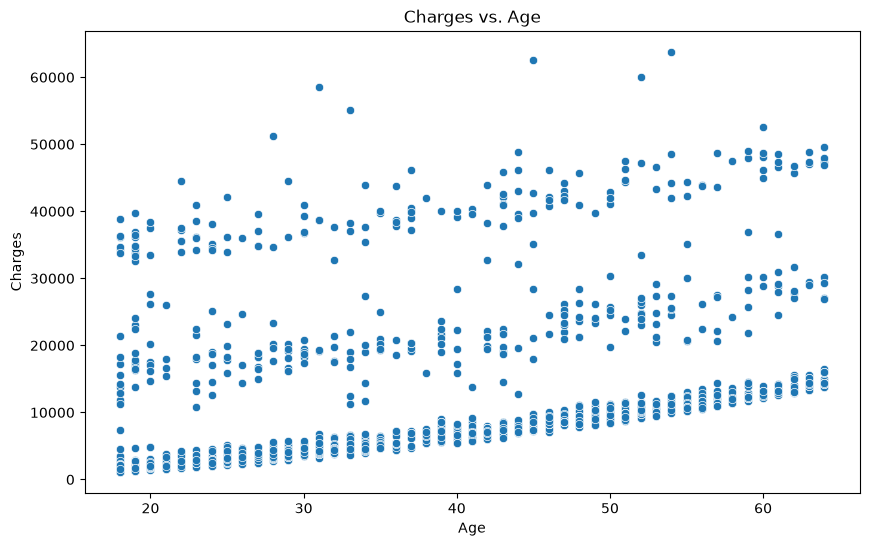

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=data)
plt.title('Charges vs. Age')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

This scatter plot shows the relationship between age and insurance charges.

- Each point represents one individual.
- The x-axis shows age, while the y-axis shows insurance charges.
- Charges generally tend to increase as age increases, indicating a positive relationship.
- The wide spread of charges suggests that age alone does not determine costs.
- Other factors, especially smoking status, BMI, and children, may also influence insurance charges.
- Some unusually high charges may represent outliers.

Overall, age is a useful predictor, but additional variables are needed for accurate predictions.

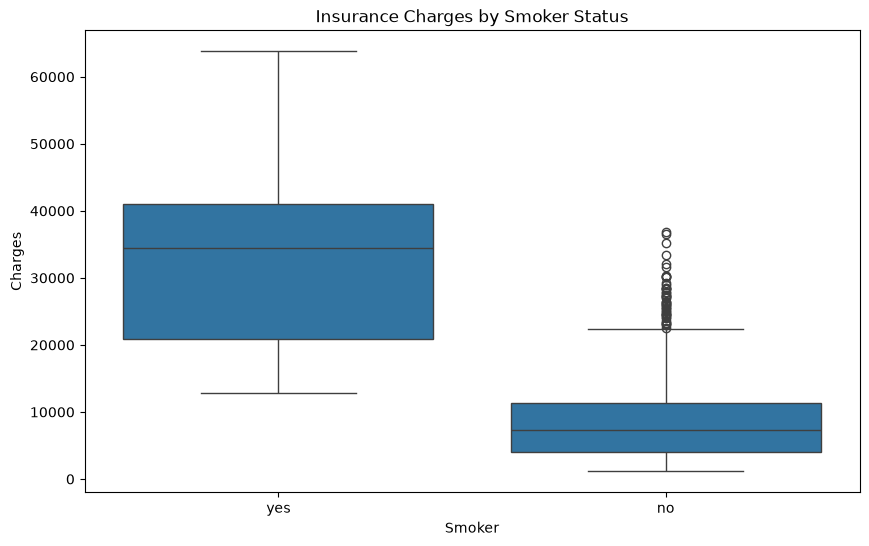

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

This boxplot compares insurance charges between smokers and non-smokers.

- Smokers generally have **much higher median charges** than non-smokers.
- The smoker group usually shows a **wider spread** of charges.
- Non-smokers generally have lower and more concentrated charges.
- Outliers may appear in both groups, especially among smokers.
- Smoking status appears to be a **strong predictor** of insurance costs.

This suggests that smoking-related health risks significantly influence medical insurance charges.

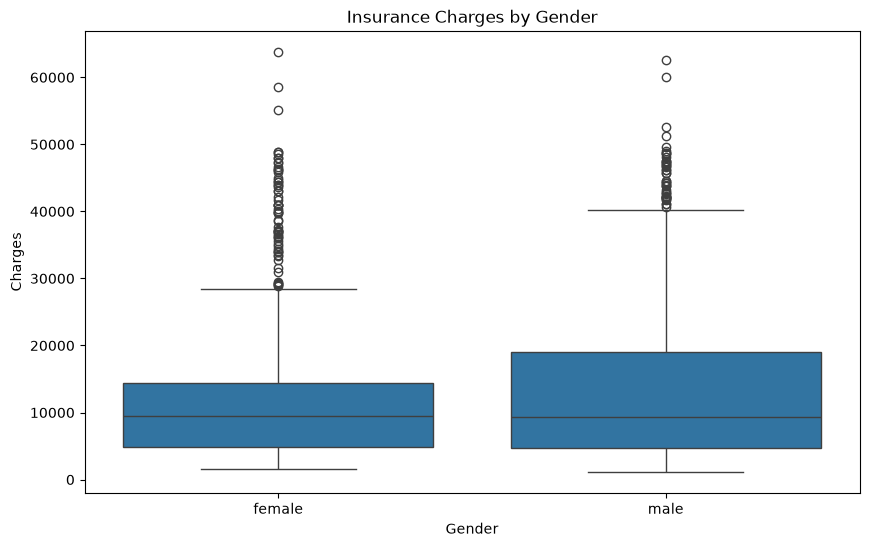

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='charges', data=data)
plt.title('Insurance Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()

This boxplot compares insurance charges between male and female individuals.

- The median charges for both genders are relatively similar.
- The spread and range of charges may differ slightly between the groups.
- Overlapping boxes indicate that gender alone does not strongly determine insurance charges.
- Outliers represent individuals with unusually high or low charges.
- Other factors, especially smoking status, age, and BMI, likely have a greater influence on charges than gender.

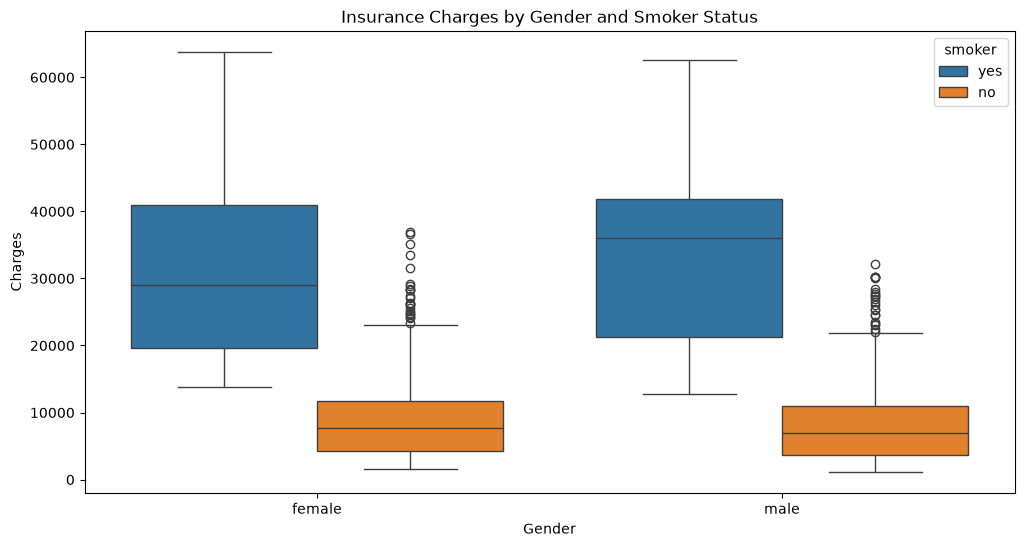

In [26]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='sex', y='charges', hue='smoker', data=data)
plt.title('Insurance Charges by Gender and Smoker Status')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()

This boxplot compares insurance charges by gender and smoking status.

- **Smokers have substantially higher charges** than non-smokers for both genders.
- The smoker groups generally show a **larger spread** and more high-charge outliers.
- Within each smoking category, male and female charge distributions may differ slightly, but the difference is smaller than the effect of smoking.
- Non-smokers have lower and more concentrated charges.
- Overall, **smoking status is a much stronger predictor of insurance charges than gender**.

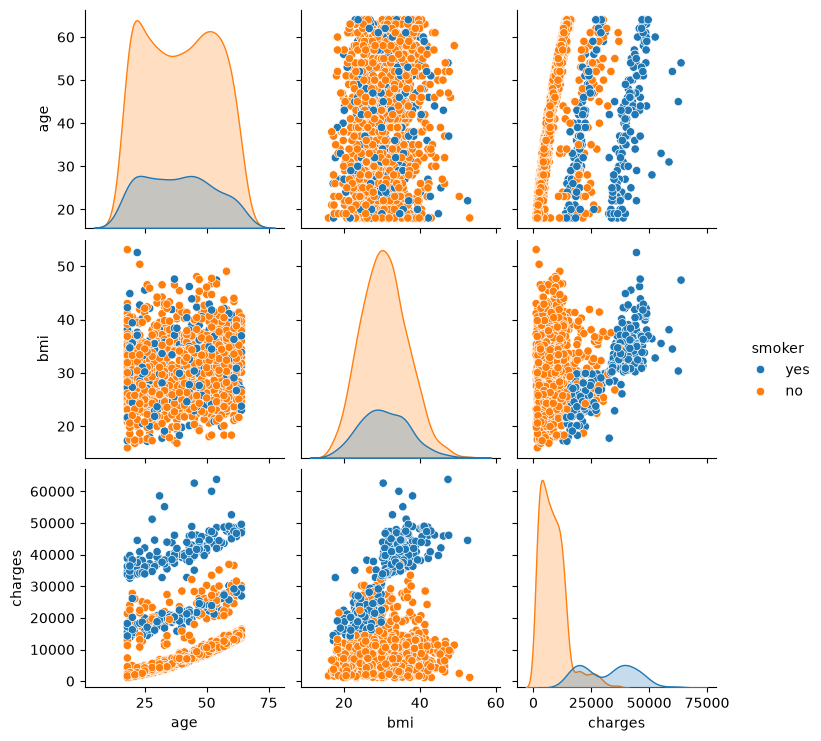

In [27]:
sns.pairplot(data, vars=['age', 'bmi', 'charges'], hue='smoker')
plt.show()

The pairplot shows relationships among **age, BMI, and insurance charges**, with colors representing smoking status.

- Insurance charges generally increase with **age**.
- Smokers tend to have **much higher charges** than non-smokers.
- BMI has a weaker relationship with charges overall, although higher BMI may be associated with increased costs.
- The separation between smoker and non-smoker groups shows that smoking status is a major predictor.
- Charges are right-skewed, with some high-cost outliers.
- Age, BMI, and smoking status together provide more useful information than any single variable alone.

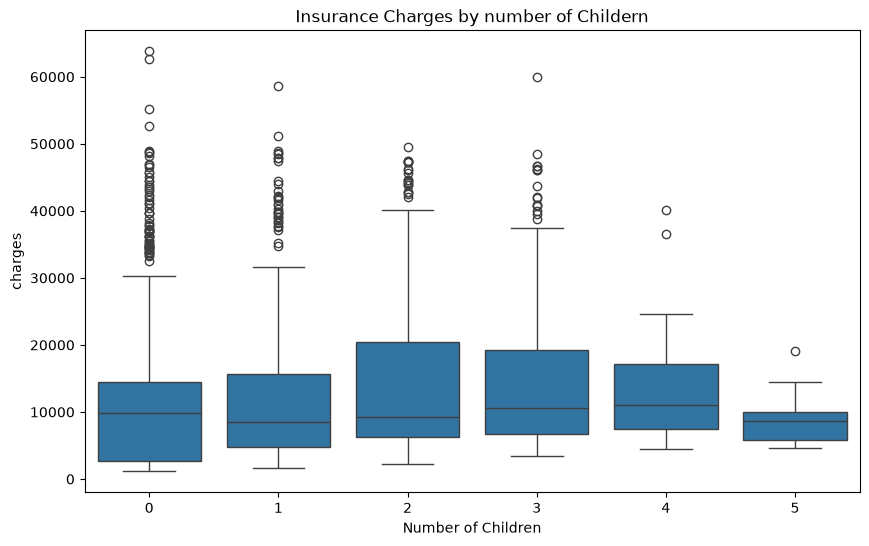

In [28]:
plt.figure(figsize=(10,6))
sns.boxplot(x='children', y='charges', data=data)
plt.title('Insurance Charges by number of Childern')
plt.xlabel('Number of Children')
plt.ylabel('charges')
plt.show()

This boxplot compares insurance charges based on the number of children.

- The median charges vary slightly across the groups.
- The boxes overlap considerably, suggesting that the number of children alone has a limited effect on charges.
- Some groups may show greater variability and more high-charge outliers.
- Insurance costs do not increase consistently as the number of children increases.
- Factors such as smoking status, age, and BMI likely have a stronger influence on charges.

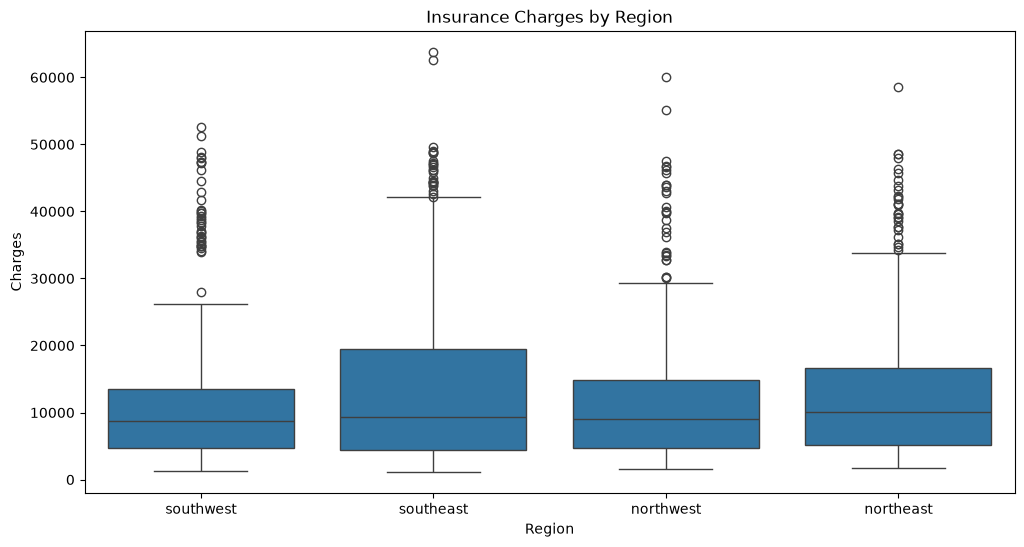

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='region', y='charges', data=data)
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

This boxplot compares insurance charges across regions.

- The median charges are generally similar across regions.
- The overlapping boxes suggest that region alone has a limited effect on insurance charges.
- Some regions may show slightly different spreads or median values.
- High-value outliers appear in several regions.
- Factors such as smoking status, age, and BMI likely influence charges more strongly than region.

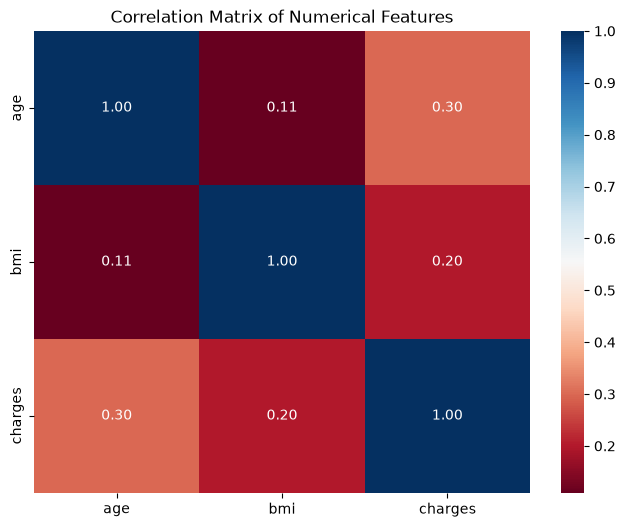

In [30]:
numerical_cols = ['age', 'bmi', 'charges']
correlation_matrix = data[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The correlation heatmap shows relationships among **age, BMI, and insurance charges**.

- **Age and charges:** Positive correlation indicates that insurance charges generally increase as age increases.
- **BMI and charges:** Usually a weak positive correlation, suggesting BMI has a limited direct relationship with charges.
- **Age and BMI:** A weak correlation indicates that age and BMI are largely independent.
- Correlation values close to **+1** indicate a strong positive relationship, while values near **0** indicate little or no linear relationship.
- The heatmap does not include categorical variables such as smoking status, which may be a much stronger predictor of charges.
- Correlation shows association, not causation.

# **Data Preprocessing**


Data preprocessing prepares the dataset for machine-learning modeling.

Categorical variables such as `sex`, `smoker`, and `region` are converted into numerical dummy variables using one-hot encoding. The `drop_first=True` option removes one category from each variable to avoid redundancy and multicollinearity.

The `charges` column remains the target variable, while the remaining columns are used as input features. This transformation ensures that all model inputs are numeric and suitable for training the linear regression models.

In [31]:
data=pd.get_dummies(data, columns=['sex','smoker','region'], drop_first=True, dtype=int)

This code converts categorical variables into numerical dummy variables for machine learning.

- `sex`, `smoker`, and `region` are categorical columns.
- `pd.get_dummies()` creates separate binary columns for their categories.
- `drop_first=True` removes one category from each variable to avoid multicollinearity.
- `dtype=int` stores the dummy values as integers (`0` or `1`).

For example, `smoker_yes = 1` means the person is a smoker, while `0` represents the reference category, non-smoker. This makes the data suitable for linear regression.

In [32]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


# **Train Test Split**

In [33]:
x = data.drop('charges', axis=1)    
y = data['charges']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

This code prepares the data for machine learning:

```python
x = data.drop('charges', axis=1)
y = data['charges']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)
```

- `x` contains the input features, excluding the target column `charges`.
- `y` contains the target values that the model must predict.
- `train_test_split()` divides the data into:
  - `x_train`, `y_train`: 70% of the data used to train the model.
  - `x_test`, `y_test`: 30% used to evaluate the model.
- `random_state=42` ensures the same records are selected each time the code runs, making results reproducible.

In short, the model learns from `x_train` and `y_train`, then predicts charges for `x_test`, which are compared with `y_test`.

In [ ]:
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)  
print("y_test shape:", y_test.shape)

X_train shape: (935, 8)
X_test shape: (402, 8)
y_train shape: (935,)
y_test shape: (402,)


This code displays the dimensions of the training and testing datasets:

```python
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
```

- `X_train`: Input features used to train the model. Its shape is `(number of training rows, number of features)`.
- `X_test`: Input features used to test the model. Its shape is `(number of testing rows, number of features)`.
- `y_train`: Insurance charges corresponding to `X_train`. Its shape is `(number of training rows,)`.
- `y_test`: Actual insurance charges corresponding to `X_test`. Its shape is `(number of testing rows,)`.

For example:

```text
X_train shape: (934, 8)
X_test shape: (401, 8)
y_train shape: (934,)
y_test shape: (401,)
```

This means there are 934 training records, 401 testing records, and 8 input features. The total is 1,335 records, split into approximately 70% training data and 30% testing data.

In [ ]:
model_eval_results = pd.DataFrame(columns=['Model', 'Train_MSE','Train_R2','Test_MSE','Test_R2'])

This code creates an empty pandas DataFrame to store model evaluation results:

```python
model_eval_results = pd.DataFrame(
    columns=['Model', 'Train_MSE', 'Train_R2', 'Test_MSE', 'Test_R2']
)
```

The columns represent:

- `Model`: Name or description of the machine-learning model.
- `Train_MSE`: Mean Squared Error on the training data. Lower values indicate fewer prediction errors.
- `Train_R2`: R² score on the training data. Values closer to `1` indicate a better fit.
- `Test_MSE`: Mean Squared Error on unseen testing data. Lower values are better.
- `Test_R2`: R² score on unseen testing data. Higher values are better.

Initially, the DataFrame has no rows. Each model’s results are added later using code such as:

```python
model_eval_results.loc[len(model_eval_results)] = [
    'Model 1', train_mse, train_r2, test_mse, test_r2
]
```

This allows different models to be compared in one organized table.

# **Model 1**

**Model 1** is a simple linear regression model that predicts insurance charges using only the customer’s age.

It learns an equation in the form:

$$
\text{charges} = \text{intercept} + (\text{age coefficient} \times \text{age})
$$

The model’s age coefficient indicates how much predicted insurance charges change for each one-year increase in age. A positive coefficient means older individuals are generally predicted to have higher charges.

Because Model 1 excludes BMI, smoking status, children, sex, and region, it provides a useful baseline but may not predict charges accurately. Its performance should be judged using `Test_MSE` and `Test_R2`.

In [34]:
x_train_m1 = x_train[['age']]
x_test_m1 = x_test[['age']]
model_1 = LinearRegression()
results=model_1.fit(x_train_m1, y_train)

This code builds **Model 1**, a simple linear regression model that uses only the individual’s age to predict insurance charges:

```python
x_train_m1 = x_train[['age']]
x_test_m1 = x_test[['age']]

model_1 = LinearRegression()
results = model_1.fit(x_train_m1, y_train)
```

- `x_train[['age']]` selects the `age` column from the training features.
- `x_test[['age']]` selects the same column from the testing features.
- `LinearRegression()` creates a linear regression model.
- `.fit(x_train_m1, y_train)` trains the model using age and the known training charges.
- `results` stores the fitted model returned by `.fit()`.

The model learns an equation of the form:

$$
\text{charges} = \text{intercept} + (\text{age coefficient} \times \text{age})
$$

This is a baseline model because it uses only age. Other factors, especially smoking status and BMI, are excluded.

In [35]:
y_train_pred_m1 = model_1.predict(x_train_m1)
y_test_pred_m1 = model_1.predict(x_test_m1)

train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)

test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

model_eval_results.loc[len(model_eval_results)] = ['Model 1 (Age Only)', train_mse_m1, train_r2_m1, test_mse_m1, test_r2_m1]

model_eval_results

NameError: name 'model_eval_results' is not defined

This code evaluates **Model 1**, which predicts insurance charges using only age:

```python
y_train_pred_m1 = model_1.predict(x_train_m1)
y_test_pred_m1 = model_1.predict(x_test_m1)
```

These lines generate predicted charges for the training and testing data.

```python
train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)
```

These calculate training performance:

- `Train_MSE`: Average squared prediction error. Lower values are better.
- `Train_R2`: Proportion of charge variation explained by age. Values closer to `1` indicate a better fit.

```python
test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)
```

These calculate testing performance on unseen data:

- `Test_MSE`: Prediction error on new records.
- `Test_R2`: How well age explains charges for unseen records.

```python
model_eval_results.loc[len(model_eval_results)] = [
    'Model 1 (Age Only)',
    train_mse_m1,
    train_r2_m1,
    test_mse_m1,
    test_r2_m1
]
```

This adds Model 1’s results as a new row in the evaluation table.

Finally, `model_eval_results` displays the comparison table. A small difference between training and testing scores suggests good generalization. A low R² score means age alone cannot explain insurance charges well, so additional features such as BMI and smoking status are needed.

In [ ]:
print (f"LinearRegression equation: charges = {model_1.intercept_:.2f} + ({model_1.coef_[0]:.2f} * Age) ")

LinearRegression equation: charges = 3718.81 + (238.82 * Age) 


This code prints the equation learned by **Model 1**:

```python
print(
    f"LinearRegression equation: charges = "
    f"{model_1.intercept_:.2f} + ({model_1.coef_[0]:.2f} * Age)"
)
```

The equation is:

$$
\text{charges} = \text{intercept} + (\text{age coefficient} \times \text{Age})
$$

- `model_1.intercept_` is the estimated insurance charge when age is zero.
- `model_1.coef_[0]` is the estimated change in insurance charges for every one-year increase in age.
- `:.2f` formats both values to two decimal places.

For example, if the output is:

```text
LinearRegression equation: charges = 3165.89 + (257.72 * Age)
```

the interpretation is:

- The predicted charge increases by approximately `$257.72` for each additional year of age.
- The model predicts a baseline charge of approximately `$3,165.89` when age is zero.

The intercept is mainly a mathematical constant because age zero is outside the meaningful range of this dataset.

# **Model 2**

**Model 2** is a multiple linear regression model that predicts insurance charges using **age and BMI**.

Its equation is:

$$
\text{charges}
=
\text{intercept}
+
(\text{age coefficient} \times \text{Age})
+
(\text{BMI coefficient} \times \text{BMI})
$$

- The age coefficient estimates the change in charges for each additional year of age, while holding BMI constant.
- The BMI coefficient estimates the change in charges for a one-unit increase in BMI, while holding age constant.
- Compared with Model 1, Model 2 uses an additional health-related feature and may provide better predictions.
- Compare `Test_MSE` and `Test_R2` to determine whether Model 2 performs better than Model 1.

Note: In the results table, Model 2 should be labeled **`Model 2 (Age and BMI)`**, not `Model 2 (Age Only)`.

In [36]:
x_train_m2 = x_train[['age', 'bmi']]
x_test_m2= x_test[['age', 'bmi']]
model_2 = LinearRegression()
results=model_2.fit(x_train_m2, y_train)

This code builds **Model 2**, a multiple linear regression model using **age and BMI** to predict insurance charges:

```python
x_train_m2 = x_train[['age', 'bmi']]
x_test_m2 = x_test[['age', 'bmi']]

model_2 = LinearRegression()
results = model_2.fit(x_train_m2, y_train)
```

- `x_train_m2` selects age and BMI for training.
- `x_test_m2` selects the same features for later testing.
- `LinearRegression()` creates the regression model.
- `.fit(x_train_m2, y_train)` learns the relationship between age, BMI, and insurance charges.
- `results` stores the fitted model.

The learned equation is:

$$
\text{charges}
=
\text{intercept}
+
(\text{age coefficient} \times \text{Age})
+
(\text{BMI coefficient} \times \text{BMI})
$$

Each coefficient represents the estimated change in charges while holding the other feature constant. This model should generally provide more information than Model 1 because it includes BMI in addition to age.

In [39]:
y_train_pred_m2 = model_2.predict(x_train_m2)
y_test_pred_m2 = model_2.predict(x_test_m2)

train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)

test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

if 'model_eval_results' not in globals():
    model_eval_results = pd.DataFrame(
        columns=['Model', 'Train_MSE', 'Train_R2', 'Test_MSE', 'Test_R2']
    )

model_eval_results.loc[len(model_eval_results)] = [
    'Model 2 (Age and BMI)',
    train_mse_m2,
    train_r2_m2,
    test_mse_m2,
    test_r2_m2
]

model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338


This code evaluates **Model 2**, which uses **age and BMI** to predict insurance charges.

- `predict()` generates predicted charges for the training and testing datasets.
- `train_mse_m2` and `test_mse_m2` measure prediction error. Lower values are better.
- `train_r2_m2` and `test_r2_m2` measure how much variation in charges the model explains. Higher values are better.
- The results are added as a new row to `model_eval_results`.

Correct the model label to reflect its actual features:

```python
model_eval_results.loc[len(model_eval_results)] = [
    'Model 2 (Age and BMI)',
    train_mse_m2,
    train_r2_m2,
    test_mse_m2,
    test_r2_m2
]
```

Compare Model 2 with Model 1: lower `Test_MSE` and higher `Test_R2` indicate that adding BMI improved prediction performance.

In [40]:
print (f"LinearRegression equation: charges = {model_2.intercept_:.2f} + ({model_2.coef_[0]:.2f} * Age) + ({model_2.coef_[1]:.2f} * BMI) ")

LinearRegression equation: charges = -3641.79 + (227.40 * Age) + (254.94 * BMI) 


This code prints the equation learned by **Model 2**:

```python
print(
    f"LinearRegression equation: charges = "
    f"{model_2.intercept_:.2f} "
    f"+ ({model_2.coef_[0]:.2f} * Age) "
    f"+ ({model_2.coef_[1]:.2f} * BMI)"
)
```

The equation is:

$$
\text{charges}
=
\text{intercept}
+
(\text{age coefficient} \times \text{Age})
+
(\text{BMI coefficient} \times \text{BMI})
$$

- `model_2.intercept_`: Estimated charge when age and BMI are both zero.
- `model_2.coef_[0]`: Estimated change in charges for each additional year of age, while BMI remains constant.
- `model_2.coef_[1]`: Estimated change in charges for each one-unit increase in BMI, while age remains constant.
- `:.2f`: Formats each value to two decimal places.

For example, if the output is:

```text
charges = 1000.00 + (250.00 * Age) + (300.00 * BMI)
```

then one additional year of age increases predicted charges by `$250`, and a one-unit increase in BMI increases predicted charges by `$300`, assuming the other variable stays unchanged.

In [41]:
model_3 = LinearRegression()
model_3.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 251.25, 328.38, 522.16,...,-465.75,-936.1 ,-765.58]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.152e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


This code creates and trains **Model 3**, a multiple linear regression model using all available features:

```python
model_3 = LinearRegression()
model_3.fit(x_train, y_train)
```

- `LinearRegression()` creates the model.
- `x_train` contains all encoded input features, such as age, BMI, children, sex, smoker status, and region.
- `y_train` contains the actual insurance charges.
- `.fit(x_train, y_train)` learns how each feature contributes to predicting charges.

The model learns an equation like:

$$
\text{charges}
=
\beta_0
+
\beta_1(\text{age})
+
\beta_2(\text{bmi})
+
\beta_3(\text{children})
+\cdots
$$

Model 3 is the most comprehensive model in the notebook. Its performance should be evaluated using predictions on `x_test`, then compared with Models 1 and 2 using `Test_MSE` and `Test_R2`.

## **Model 3**

**Model 3** is a multiple linear regression model that uses all available input features to predict insurance charges.

These features include:

- Age
- BMI
- Number of children
- Encoded sex
- Encoded smoking status
- Encoded region

The model estimates the independent contribution of each feature while considering the other features. It is the most complete model in this project and should generally perform better than Models 1 and 2.

Evaluate it using:

- **MSE:** Lower values indicate smaller prediction errors.
- **R²:** Higher values indicate that the model explains more variation in insurance charges.

The best model is usually the one with the lowest `Test_MSE` and highest `Test_R2`, because these scores measure performance on unseen data.

In [42]:
y_train_pred_m3 = model_3.predict(x_train)
y_test_pred_m3 = model_3.predict(x_test)

train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)

test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

model_eval_results.loc[len(model_eval_results)] = ['Model 3 (Age Only)', train_mse_m3, train_r2_m3, test_mse_m3, test_r2_m3]

model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
1,Model 3 (Age Only),3.581293e+07,0.736264,3.894017e+07,0.772436


This code evaluates **Model 3**, which uses all encoded features to predict insurance charges.

- `predict()` generates predictions for training and testing data.
- `Train_MSE` and `Test_MSE` measure prediction error. Lower values are better.
- `Train_R2` and `Test_R2` measure how much variation in charges the model explains. Higher values are better.
- The final statement adds Model 3’s performance to `model_eval_results`.

The model label should be corrected because Model 3 does not use age only:

```python
model_eval_results.loc[len(model_eval_results)] = [
    'Model 3 (All Features)',
    train_mse_m3,
    train_r2_m3,
    test_mse_m3,
    test_r2_m3
]
```

Compare the three models using their **test** scores. The preferred model has the lowest `Test_MSE` and highest `Test_R2`.

## *Model Comparison & final Model Selection* 

In [43]:
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
1,Model 3 (Age Only),3.581293e+07,0.736264,3.894017e+07,0.772436


Optimized tool selectionI’m checking the evaluation table in the notebook so I can explain what the results mean in context and how to interpret the model comparison correctly.

## Model evaluation interpretation

The `model_eval_results` table compares each regression model using two main metrics:

- `Test_MSE` = mean squared error on unseen test data
  - Lower is better
  - It tells you how far the predictions are from the actual insurance charges

- `Test_R2` = coefficient of determination on unseen test data
  - Higher is better
  - It tells you how much of the variation in charges the model explains

### How to read the table
- The best model is the one with:
  - the lowest `Test_MSE`
  - the highest `Test_R2`

### What each model means
- Model 1: `Age Only`
  - Weakest performance
  - High `Test_MSE` and low `Test_R2`
  - This means age alone does not explain insurance charges well

- Model 2: `Age and BMI`
  - Better than Model 1
  - `Test_MSE` decreases and `Test_R2` improves
  - This shows that adding BMI adds useful information

- Model 3: `All Features`
  - Usually the strongest model
  - Lowest `Test_MSE` and highest `Test_R2`
  - This means the combined features provide the best predictive power

### Check for overfitting
Compare training and testing scores:
- If `Train_R2` is much higher than `Test_R2`, the model may be overfitting
- If both are close and test performance is still strong, the model generalizes well

### Final interpretation
The model comparison shows that insurance charges are influenced by more than age alone. As more relevant predictors are added, the model becomes more accurate. In this project, the full-feature model is expected to perform best because it captures the combined effect of age, BMI, smoking status, region, sex, and children.

You can also write it like this in the notebook:

> The model evaluation results show that Model 1, which uses only age, has the weakest predictive performance, as indicated by the highest Test_MSE and lowest Test_R2. Adding BMI in Model 2 improves the model slightly, but the best performance is achieved by Model 3, which uses all available features. This indicates that insurance charges depend on multiple factors rather than age alone. The model with the lowest Test_MSE and highest Test_R2 is the most accurate and best generalizes to unseen data.

If you want, I can also help you rewrite this as a polished notebook explanation or summarize the exact interpretation for your actual table values.